<a href="https://colab.research.google.com/github/soulqan/PCVK_GANJIL_2025/blob/main/WEEK5_28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#D1-Percobaan Histogram

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

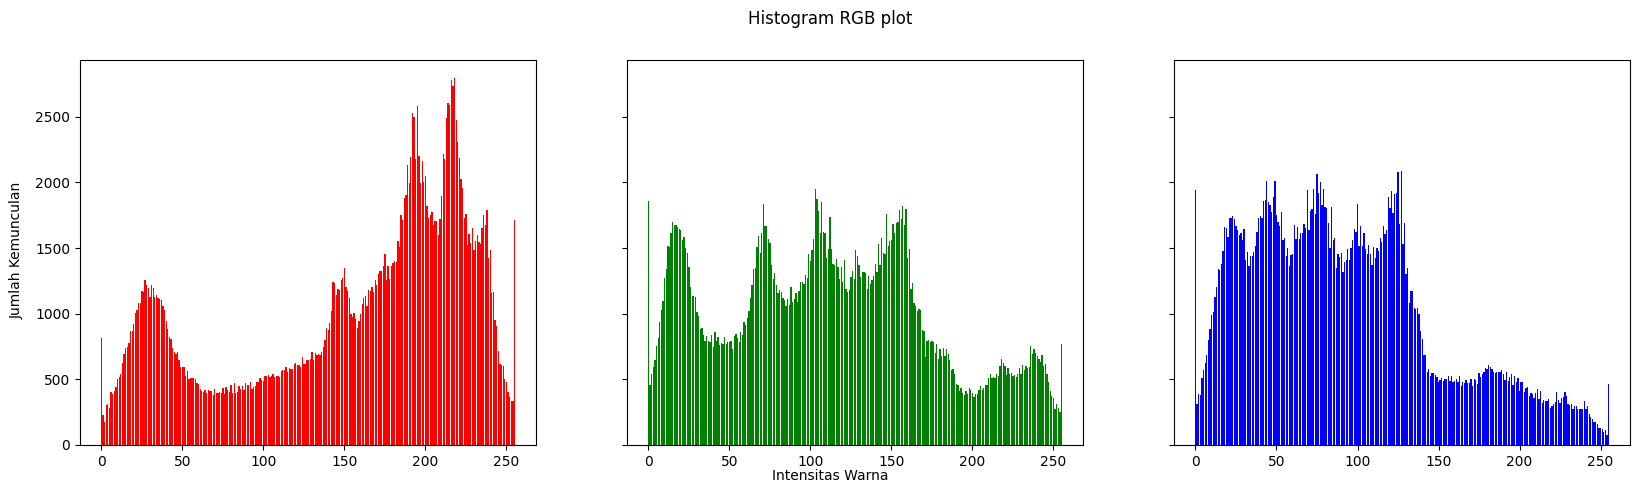

In [11]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')


**PERTANYAAN PRAKTIKUM D1**
1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh
NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?
Jawaban: Hasilnya sama saja seperti cara yang tidak menggunakan numpy

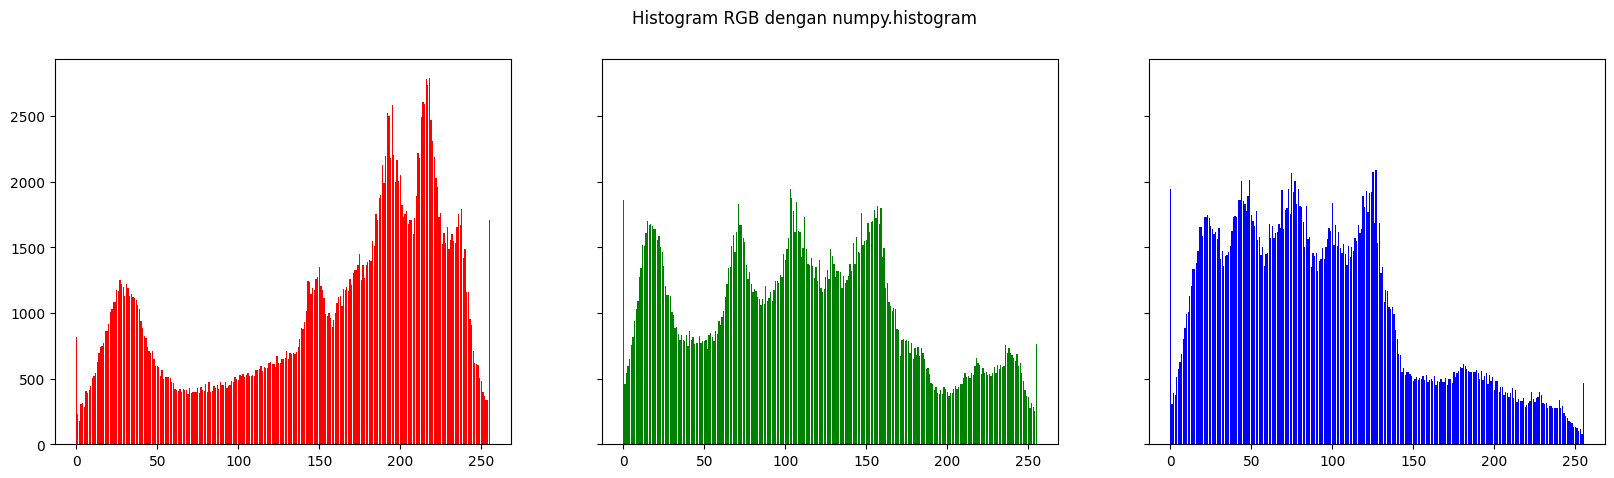

In [13]:
img = cv.imread('/content/drive/MyDrive/images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img)

hist_r, bins_r = np.histogram(r.flatten(), bins=256, range=[0,256])
hist_g, bins_g = np.histogram(g.flatten(), bins=256, range=[0,256])
hist_b, bins_b = np.histogram(b.flatten(), bins=256, range=[0,256])

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB dengan numpy.histogram')

axs[0].bar(range(256), hist_r, color='red')
axs[1].bar(range(256), hist_g, color='green')
axs[2].bar(range(256), hist_b, color='blue')

plt.show()

2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.
Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung
gelap, terang, atau kontras rendah.
JAwaban: gambar cenderung terang dengan kontras sedang/rendah, karena distribusi intensitas terkonsentrasi di rentang menengah-terang (150-220) dan sedikit pada area gelap.

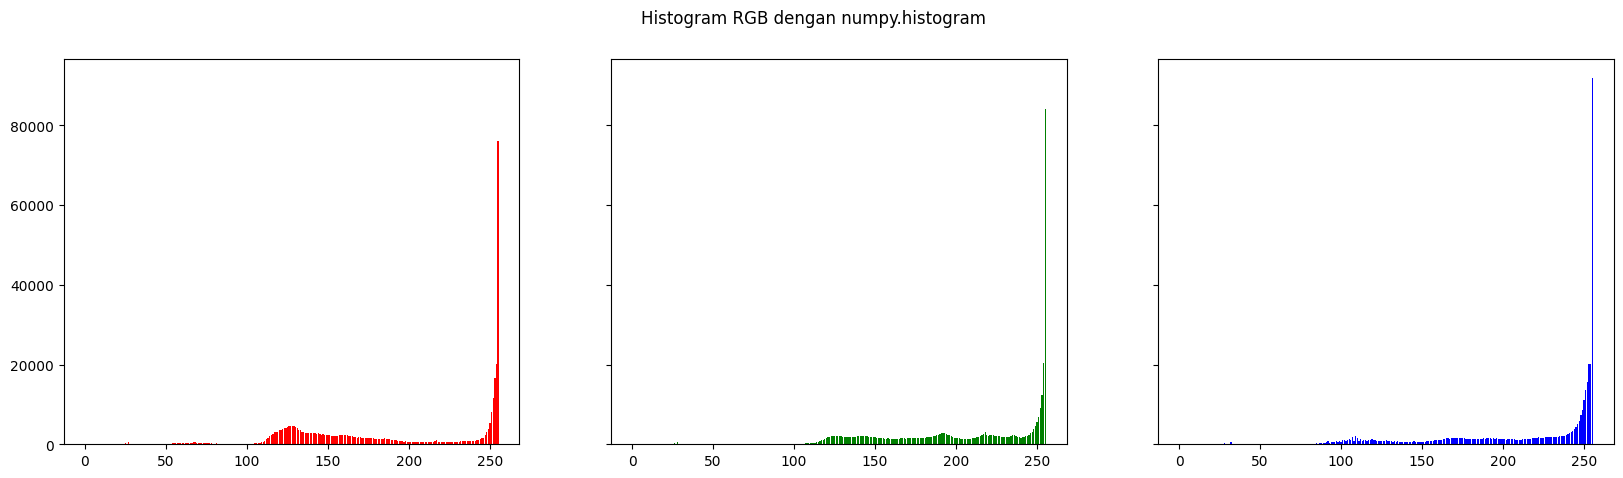

In [15]:
img = cv.imread('/content/drive/MyDrive/images/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img)

hist_r, bins_r = np.histogram(r.flatten(), bins=256, range=[0,256])
hist_g, bins_g = np.histogram(g.flatten(), bins=256, range=[0,256])
hist_b, bins_b = np.histogram(b.flatten(), bins=256, range=[0,256])

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB dengan numpy.histogram')

axs[0].bar(range(256), hist_r, color='red')
axs[1].bar(range(256), hist_g, color='green')
axs[2].bar(range(256), hist_b, color='blue')

plt.show()

#D2-PERCOBAAN HISTOGRAM EQUALIZATION

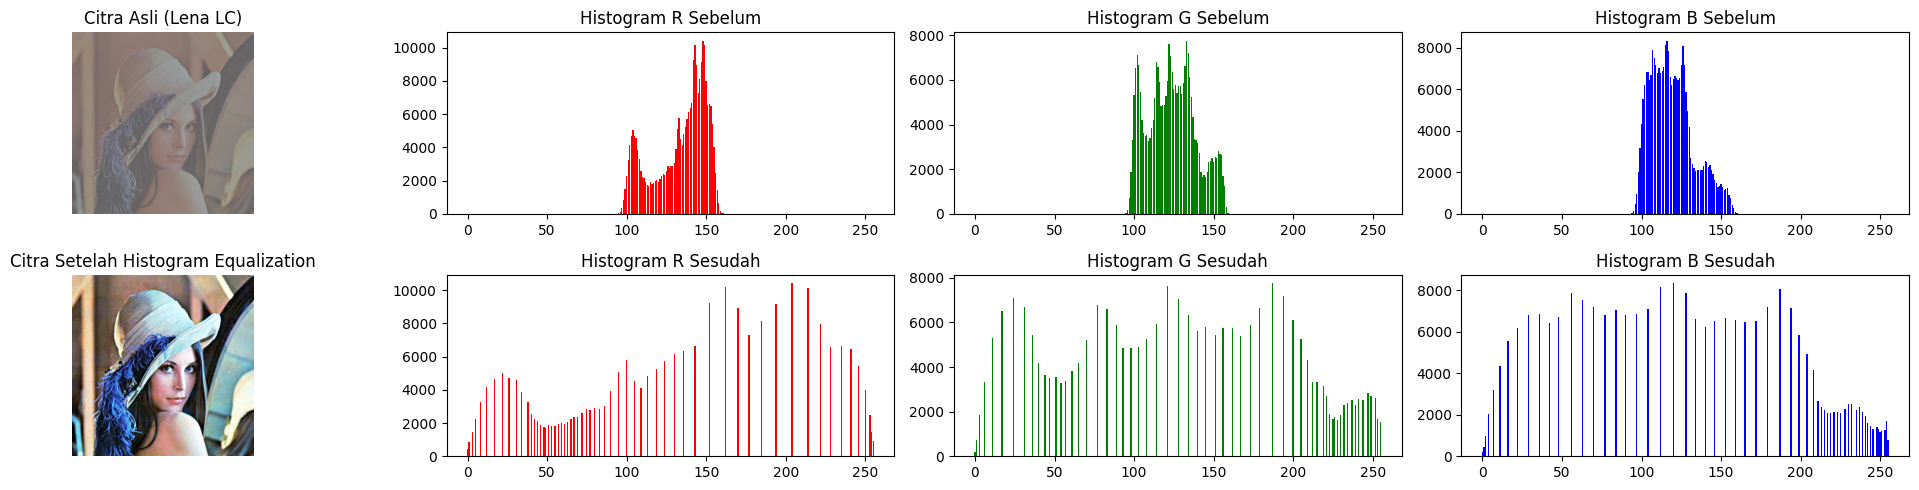

In [22]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar RGB (low contrast)
img = cv.imread('/content/drive/MyDrive/images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split channel
r, g, b = cv.split(img)

# Equalization per channel
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali
equ = cv.merge([r_eq, g_eq, b_eq])

# Hitung histogram sebelum
red_hist, _ = np.histogram(r.ravel(), bins=256, range=(0,256))
green_hist, _ = np.histogram(g.ravel(), bins=256, range=(0,256))
blue_hist, _ = np.histogram(b.ravel(), bins=256, range=(0,256))

# Hitung histogram sesudah
red_hist_eq, _ = np.histogram(r_eq.ravel(), bins=256, range=(0,256))
green_hist_eq, _ = np.histogram(g_eq.ravel(), bins=256, range=(0,256))
blue_hist_eq, _ = np.histogram(b_eq.ravel(), bins=256, range=(0,256))

names = np.arange(256)

# Plot hasil citra dan histogram
fig, axs = plt.subplots(2, 4, figsize=(20,5))

# Baris atas: citra asli + histogram R,G,B sebelum
axs[0,0].imshow(img)
axs[0,0].set_title("Citra Asli (Lena LC)")
axs[0,0].axis("off")

axs[0,1].bar(names, red_hist, color='red')
axs[0,1].set_title("Histogram R Sebelum")

axs[0,2].bar(names, green_hist, color='green')
axs[0,2].set_title("Histogram G Sebelum")

axs[0,3].bar(names, blue_hist, color='blue')
axs[0,3].set_title("Histogram B Sebelum")

# Baris bawah: citra hasil equalization + histogram R,G,B sesudah
axs[1,0].imshow(equ)
axs[1,0].set_title("Citra Setelah Histogram Equalization")
axs[1,0].axis("off")

axs[1,1].bar(names, red_hist_eq, color='red')
axs[1,1].set_title("Histogram R Sesudah")

axs[1,2].bar(names, green_hist_eq, color='green')
axs[1,2].set_title("Histogram G Sesudah")

axs[1,3].bar(names, blue_hist_eq, color='blue')
axs[1,3].set_title("Histogram B Sesudah")

plt.tight_layout()
plt.show()



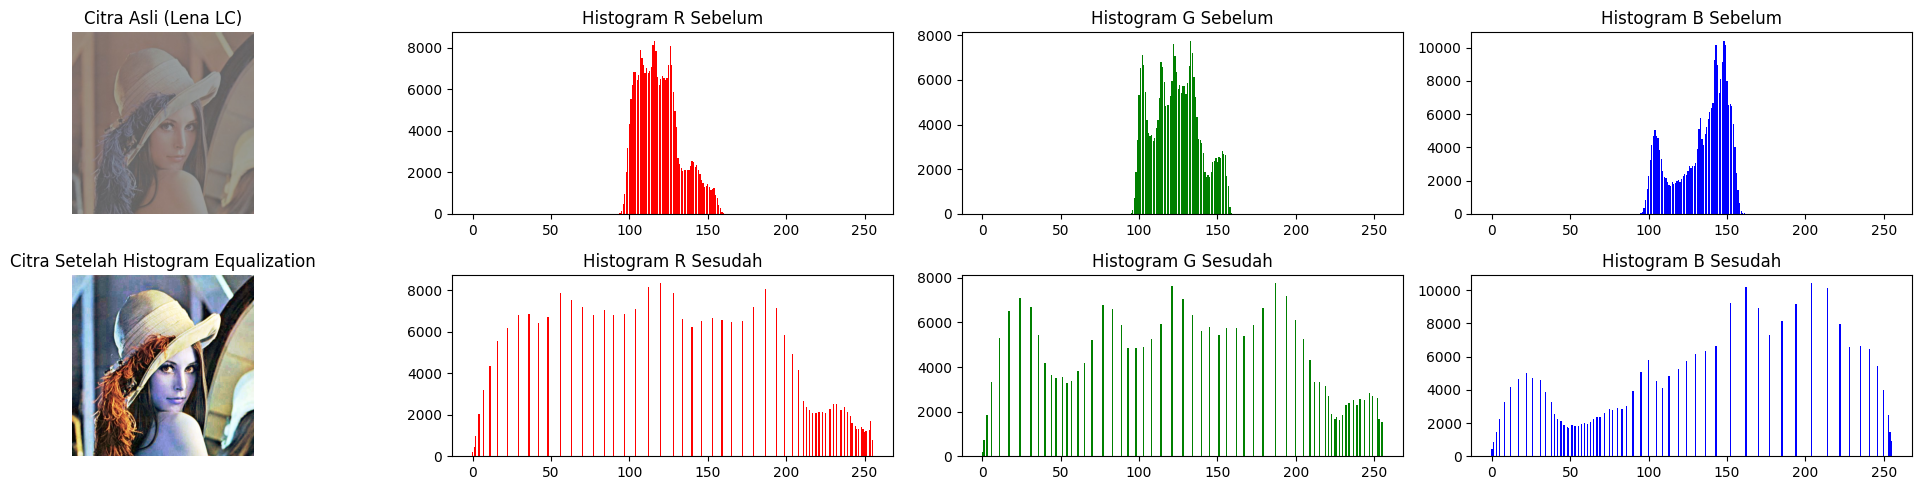

In [27]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar RGB (low contrast)
img = cv.imread('/content/drive/MyDrive/images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

b, g, r = cv.split(img)

b_eq  = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

# Gabungkan kembali
equ = cv.merge([r_eq, g_eq, b_eq])

# Hitung histogram sebelum
red_hist, _ = np.histogram(r.ravel(), bins=256, range=(0,256))
green_hist, _ = np.histogram(g.ravel(), bins=256, range=(0,256))
blue_hist, _ = np.histogram(b.ravel(), bins=256, range=(0,256))

# Hitung histogram sesudah
red_hist_eq, _ = np.histogram(r_eq.ravel(), bins=256, range=(0,256))
green_hist_eq, _ = np.histogram(g_eq.ravel(), bins=256, range=(0,256))
blue_hist_eq, _ = np.histogram(b_eq.ravel(), bins=256, range=(0,256))

names = np.arange(256)

# Plot hasil citra dan histogram
fig, axs = plt.subplots(2, 4, figsize=(20,5))

# Baris atas: citra asli + histogram R,G,B sebelum
axs[0,0].imshow(img)
axs[0,0].set_title("Citra Asli (Lena LC)")
axs[0,0].axis("off")

axs[0,1].bar(names, red_hist, color='red')
axs[0,1].set_title("Histogram R Sebelum")

axs[0,2].bar(names, green_hist, color='green')
axs[0,2].set_title("Histogram G Sebelum")

axs[0,3].bar(names, blue_hist, color='blue')
axs[0,3].set_title("Histogram B Sebelum")

# Baris bawah: citra hasil equalization + histogram R,G,B sesudah
axs[1,0].imshow(equ)
axs[1,0].set_title("Citra Setelah Histogram Equalization")
axs[1,0].axis("off")

axs[1,1].bar(names, red_hist_eq, color='red')
axs[1,1].set_title("Histogram R Sesudah")

axs[1,2].bar(names, green_hist_eq, color='green')
axs[1,2].set_title("Histogram G Sesudah")

axs[1,3].bar(names, blue_hist_eq, color='blue')
axs[1,3].set_title("Histogram B Sesudah")

plt.tight_layout()
plt.show()




1. Perbandingan Citra Lena

  a. Gunakan hasil histogram equalization pada citra lena.jpg.

  b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.

  c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas visual citra? Apakah ada detail baru yang muncul setelah equalization?
  Jawaban: NIlai PSNR nya rendah dengan nilai 17.948401486845306 dB nilai yang rendah menunjukkan perbedaan besar antara citra asli dan citra yang di-equalize.

Nilai PSNR antara citra asli dan citra yang di-equalize: 17.948401486845306 dB


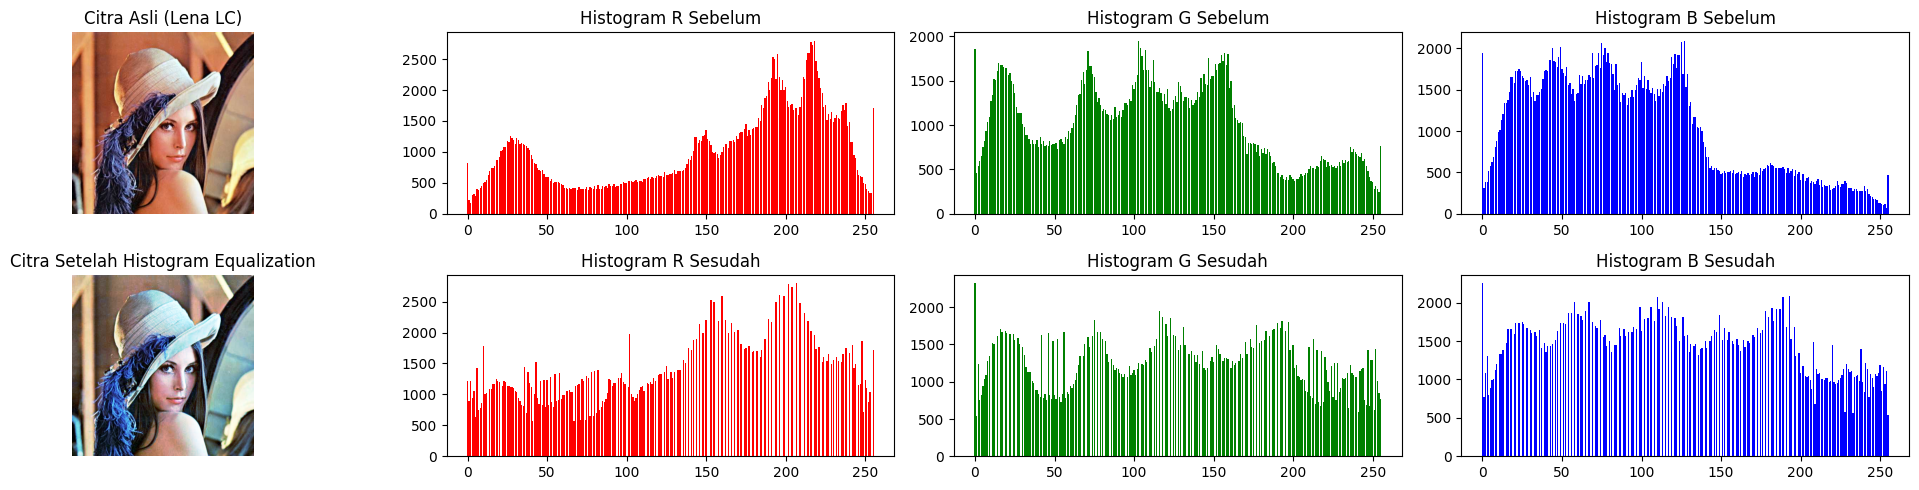

In [29]:

# Baca gambar RGB (low contrast)
img = cv.imread('/content/drive/MyDrive/images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split channel
r, g, b = cv.split(img)

# Equalization per channel
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali
equ = cv.merge([r_eq, g_eq, b_eq])

# Hitung histogram sebelum
red_hist, _ = np.histogram(r.ravel(), bins=256, range=(0,256))
green_hist, _ = np.histogram(g.ravel(), bins=256, range=(0,256))
blue_hist, _ = np.histogram(b.ravel(), bins=256, range=(0,256))

# Hitung histogram sesudah
red_hist_eq, _ = np.histogram(r_eq.ravel(), bins=256, range=(0,256))
green_hist_eq, _ = np.histogram(g_eq.ravel(), bins=256, range=(0,256))
blue_hist_eq, _ = np.histogram(b_eq.ravel(), bins=256, range=(0,256))

names = np.arange(256)

# --- Tambahan Kode untuk Perhitungan PSNR ---

# Ubah tipe data menjadi float untuk perhitungan
img_float = img.astype(np.float64)
equ_float = equ.astype(np.float64)

# Hitung Mean Squared Error (MSE)
mse = np.mean((img_float - equ_float) ** 2)

# Jika MSE adalah 0, PSNR tidak terhingga.
if mse == 0:
    psnr = "Infinity"
else:
    # MAX_I adalah nilai piksel maksimum, yaitu 255 untuk 8-bit
    MAX_I = 255.0
    psnr = 10 * np.log10(MAX_I**2 / mse)

print(f"Nilai PSNR antara citra asli dan citra yang di-equalize: {psnr} dB")

# --- Bagian Plot hasil citra dan histogram (tidak berubah) ---
fig, axs = plt.subplots(2, 4, figsize=(20,5))

# Baris atas: citra asli + histogram R,G,B sebelum
axs[0,0].imshow(img)
axs[0,0].set_title("Citra Asli (Lena LC)")
axs[0,0].axis("off")

axs[0,1].bar(names, red_hist, color='red')
axs[0,1].set_title("Histogram R Sebelum")

axs[0,2].bar(names, green_hist, color='green')
axs[0,2].set_title("Histogram G Sebelum")

axs[0,3].bar(names, blue_hist, color='blue')
axs[0,3].set_title("Histogram B Sebelum")

# Baris bawah: citra hasil equalization + histogram R,G,B sesudah
axs[1,0].imshow(equ)
axs[1,0].set_title("Citra Setelah Histogram Equalization")
axs[1,0].axis("off")

axs[1,1].bar(names, red_hist_eq, color='red')
axs[1,1].set_title("Histogram R Sesudah")

axs[1,2].bar(names, green_hist_eq, color='green')
axs[1,2].set_title("Histogram G Sesudah")

axs[1,3].bar(names, blue_hist_eq, color='blue')
axs[1,3].set_title("Histogram B Sesudah")

plt.tight_layout()
plt.show()



2. Gunakan Citra KTM Lama.jpg

  a.  Terapkan histogram equalization pada citra KTM lama.jpg.

  b.Tampilkan citra asli, citra hasil equalization, serta histogram keduanya dalam satu layout.

c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization.
Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah,
teks, atau latar belakang). Apakah perubahan tersebut meningkatkan kualitas
informasi dari citra atau justru membuat citra terlihat terlalu “keras”.

Nilai PSNR antara citra asli dan citra yang di-equalize: 9.908941379296948 dB


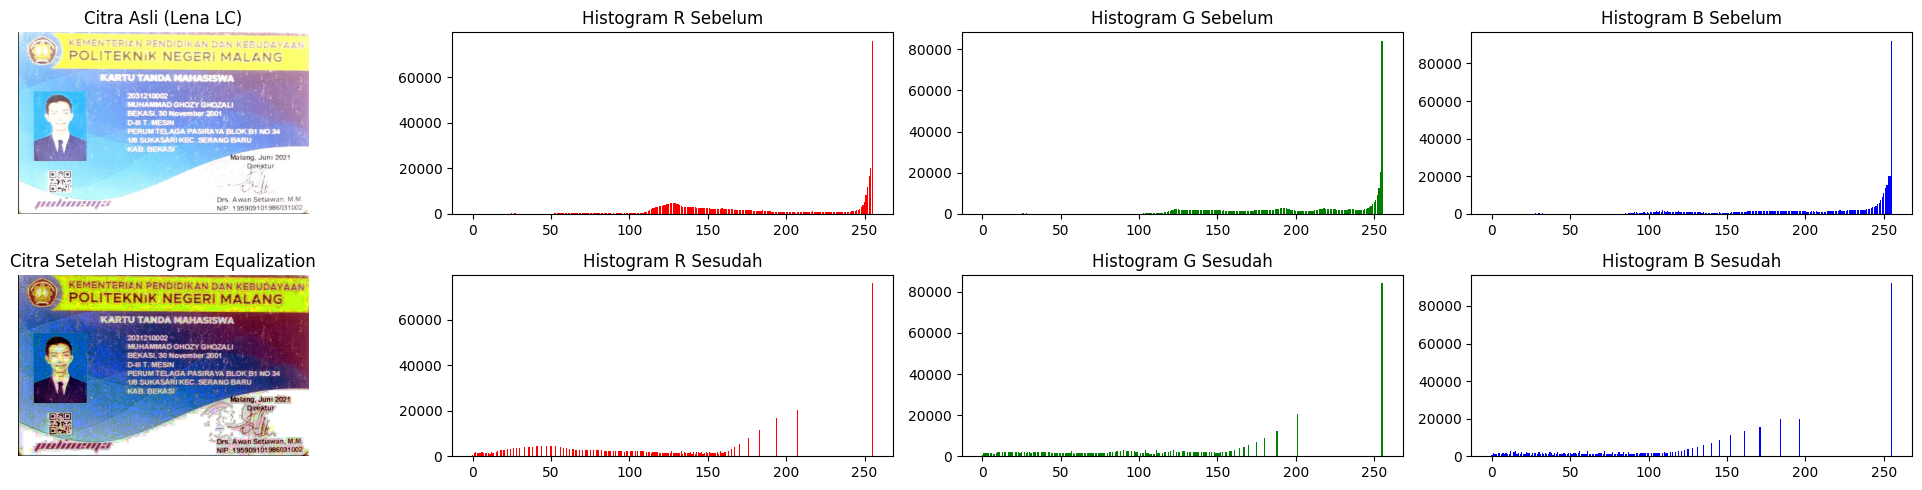

In [30]:

# Baca gambar RGB (low contrast)
img = cv.imread('/content/drive/MyDrive/images/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split channel
r, g, b = cv.split(img)

# Equalization per channel
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali
equ = cv.merge([r_eq, g_eq, b_eq])

# Hitung histogram sebelum
red_hist, _ = np.histogram(r.ravel(), bins=256, range=(0,256))
green_hist, _ = np.histogram(g.ravel(), bins=256, range=(0,256))
blue_hist, _ = np.histogram(b.ravel(), bins=256, range=(0,256))

# Hitung histogram sesudah
red_hist_eq, _ = np.histogram(r_eq.ravel(), bins=256, range=(0,256))
green_hist_eq, _ = np.histogram(g_eq.ravel(), bins=256, range=(0,256))
blue_hist_eq, _ = np.histogram(b_eq.ravel(), bins=256, range=(0,256))

names = np.arange(256)

# --- Tambahan Kode untuk Perhitungan PSNR ---

# Ubah tipe data menjadi float untuk perhitungan
img_float = img.astype(np.float64)
equ_float = equ.astype(np.float64)

# Hitung Mean Squared Error (MSE)
mse = np.mean((img_float - equ_float) ** 2)

# Jika MSE adalah 0, PSNR tidak terhingga.
if mse == 0:
    psnr = "Infinity"
else:
    # MAX_I adalah nilai piksel maksimum, yaitu 255 untuk 8-bit
    MAX_I = 255.0
    psnr = 10 * np.log10(MAX_I**2 / mse)

print(f"Nilai PSNR antara citra asli dan citra yang di-equalize: {psnr} dB")

# --- Bagian Plot hasil citra dan histogram (tidak berubah) ---
fig, axs = plt.subplots(2, 4, figsize=(20,5))

# Baris atas: citra asli + histogram R,G,B sebelum
axs[0,0].imshow(img)
axs[0,0].set_title("Citra Asli (Lena LC)")
axs[0,0].axis("off")

axs[0,1].bar(names, red_hist, color='red')
axs[0,1].set_title("Histogram R Sebelum")

axs[0,2].bar(names, green_hist, color='green')
axs[0,2].set_title("Histogram G Sebelum")

axs[0,3].bar(names, blue_hist, color='blue')
axs[0,3].set_title("Histogram B Sebelum")

# Baris bawah: citra hasil equalization + histogram R,G,B sesudah
axs[1,0].imshow(equ)
axs[1,0].set_title("Citra Setelah Histogram Equalization")
axs[1,0].axis("off")

axs[1,1].bar(names, red_hist_eq, color='red')
axs[1,1].set_title("Histogram R Sesudah")

axs[1,2].bar(names, green_hist_eq, color='green')
axs[1,2].set_title("Histogram G Sesudah")

axs[1,3].bar(names, blue_hist_eq, color='blue')
axs[1,3].set_title("Histogram B Sesudah")

plt.tight_layout()
plt.show()

